In [22]:
import time
def fib(n):
    if n == 0 or n == 1:
        return n
    else:
        return fib(n-2) + fib(n-1)
    
def count(f):
    def counted(n):
        counted.call_count += 1
        return f(n)
    counted.call_count = 0
    return counted

def memo(f):
    cache = {}
    def memoized(n):
        if n not in cache:
            cache[n] = f(n)
        return cache[n]
    return memoized

fib = count(fib)
print(fib)
counted_fib = fib
print(counted_fib)
fib = memo(fib)
print(fib)
fib = count(fib)
print(fib)
fib(5)
print(fib.call_count) # 调用了多少次memoized函数
print(counted_fib.call_count)# 实际调用了多少次fib函数

<function count.<locals>.counted at 0x7fa599aaaca0>
<function count.<locals>.counted at 0x7fa599aaaca0>
<function memo.<locals>.memoized at 0x7fa599aab600>
<function count.<locals>.counted at 0x7fa599aaac00>
9
6


In [1]:
def exp(b, n):
    if n == 0:
        return 1
    else:
        return b * exp(b, n-1)
        

In [2]:
%%time
exp(2,400)

CPU times: user 32 μs, sys: 26 μs, total: 58 μs
Wall time: 59.4 μs


2582249878086908589655919172003011874329705792829223512830659356540647622016841194629645353280137831435903171972747493376

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rc('font', size=16)

from timeit import repeat
from numpy import median, percentile

def plot_time(name, xs, n=15):
    f = lambda x : name + '(' + str(x) + ')'
    g = globals()

    samples = []
    for _ in range(n):
        times = lambda x: repeat(f(x), globals=g, number=1, repeat=n)
        samples.append([median(times(x)) for x in xs])
    ys = [10e3 * median(sample) for sample in zip(*samples)]

    plt.figure(figsize=(8,8))
    plt.plot(xs, ys)
    plt.xlabel('n')
    plt.ylabel('milliseconds')

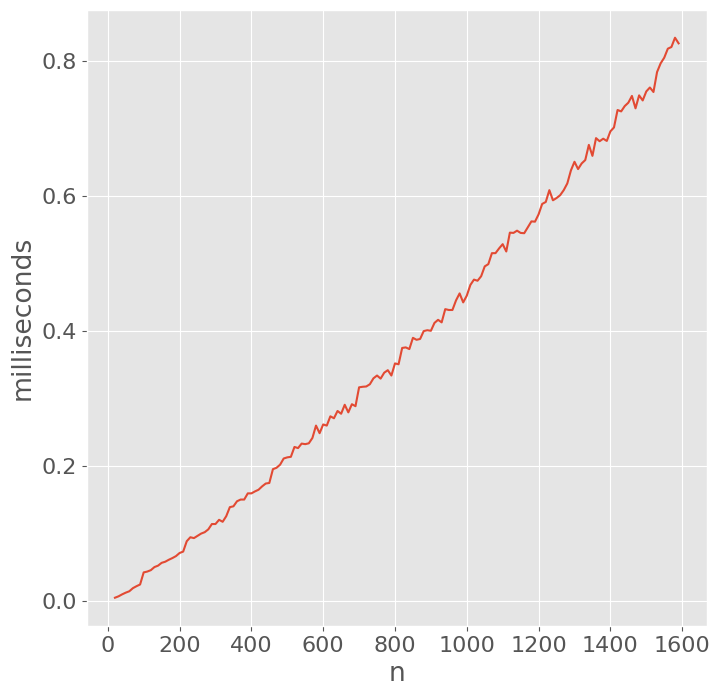

In [7]:
exp_2 = lambda n : exp(2,n)
plot_time('exp_2', range(20,1600,10))

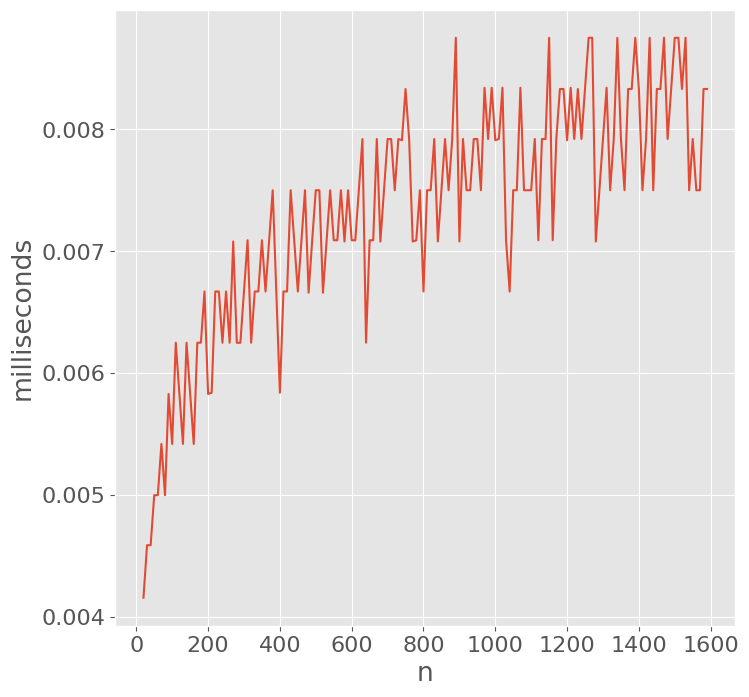

In [10]:
def exp_fast(b,n):
    if n == 0:
        return 1
    elif n % 2 == 0:
        return square(exp_fast(b,n//2))
    else:
        return b * exp_fast(b,n-1)

def square(x):
    return x * x

exp_2_fast = lambda n: exp_fast(2.0,n)
plot_time('exp_2_fast', range(20,1600,10))

In [ ]:
def overlap(a,b):
    count = 0
    for item in a:
        for other in b:
            if item == other:
                count += 1
 